# Testing SpeciesNet Model along with Megadetector

This notebook demonstrates how to:
1. Test the deployed Sagemaker endpoint
2. Run the deployed Megadetector endpoint
3. Use the results from Megadetector to run SpeciesNet in "classifier" mode
4. Visualize results with bounding boxes

## Setup

Import required libraries and set up configurations

In [2]:
%matplotlib inline
import os
import json
import base64
import requests
from pathlib import Path
import boto3
from PIL import Image, ImageDraw
from io import BytesIO
import matplotlib.pyplot as plt

## Helper Functions

In [3]:
def draw_predictions(image, predictions):
    """Draw bounding boxes and labels on the image."""
    image_draw = image.copy()
    draw = ImageDraw.Draw(image_draw)
    width, height = image.size

    for pred in predictions['predictions']:
        if 'detections' in pred:
            for det in pred['detections']:
                # Get bounding box coordinates
                bbox = det['bbox']
                x1 = bbox[0] * width
                y1 = bbox[1] * height
                x2 = (bbox[0] + bbox[2]) * width
                y2 = (bbox[1] + bbox[3]) * height

                # Draw bounding box
                draw.rectangle([x1, y1, x2, y2], outline='red', width=3)

                # Add label with confidence
                label = f"{det['category']}: {det['conf']:.2f}"
                draw.text((x1, y1-15), label, fill='red')

    return image_draw

def prepare_image(image_path):
    """Prepare image for inference by converting to base64."""
    with Image.open(image_path) as img:
        buffered = BytesIO()
        img.save(buffered, format="JPEG")
        img_str = base64.b64encode(buffered.getvalue()).decode()
    return img_str, img

def convert_md_to_speciesnet(md_detections, confidence_threshold=0.90):
    """
    Convert MegaDetector detections to SpeciesNet format and filter by confidence.
    
    Args:
        md_detections: List of MegaDetector detections, each with x1,y1,x2,y2 format
        confidence_threshold: Minimum confidence threshold (default 0.90)
    
    Returns:
        Dictionary formatted for SpeciesNet with filtered and converted detections
    """
    filtered_detections = []
    
    for det in md_detections:
        # Only process animal detections (class 1) above confidence threshold
        if det['class'] == 1 and det['confidence'] >= confidence_threshold:
            # Get coordinates
            x = det['x1']  # x1 becomes x
            y = det['y1']  # y1 becomes y
            width = det['x2'] - det['x1']   # x2 - x1 gives width
            height = det['y2'] - det['y1']  # y2 - y1 gives height
            
            # Create SpeciesNet detection format
            detection = {
                "bbox": [x, y, width, height],
                "conf": det['confidence'],
                "category": str(det['class']),  # Convert to string as SpeciesNet expects string
                "label": "animal"
            }
            filtered_detections.append(detection)
    
    # Create SpeciesNet compatible payload
    speciesnet_payload = {
        "predictions": [{
            "detections": filtered_detections
        }]
    }
    
    return speciesnet_payload

def draw_md5_detections(image, detections, confidence_threshold=0.0):
    """
    Draw bounding boxes on the image for MegaDetector detections.
    
    Args:
        image: PIL Image or path to image file
        detections: List of detection dictionaries with x1,y1,x2,y2,confidence,class
        confidence_threshold: Minimum confidence to display (default 0.0 shows all)
    
    Returns:
        PIL Image with drawn bounding boxes
    """
    # Load image if path provided
    if isinstance(image, str):
        image = Image.open(image)
    
    # Make a copy to draw on
    draw_image = image.copy()
    draw = ImageDraw.Draw(draw_image)
    
    # Get image dimensions
    width, height = image.size
    
    # Color scheme for different classes (animal=1, person=2, vehicle=3)
    colors = {
        1: "#00ff00",  # Green for animals
        2: "#ff0000",  # Red for people
        3: "#0000ff"   # Blue for vehicles
    }
    
    # Class names
    class_names = {1: "Animal", 2: "Person", 3: "Vehicle"}
    
    # Draw each detection above threshold
    for det in detections:
        if det['confidence'] >= confidence_threshold:
            # Get coordinates
            x1 = int(det['x1'] * width)
            y1 = int(det['y1'] * height)
            x2 = int(det['x2'] * width)
            y2 = int(det['y2'] * height)
            
            # Get color based on class
            color = colors.get(det['class'], "#ffffff")
            
            # Draw box
            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
            
            # Create label
            label = f"{class_names.get(det['class'], 'Unknown')}: {det['confidence']:.2f}"
            
            # Draw label
            draw.text((x1, y1-20), label, fill=color)
    
    return draw_image


# Load Image

In [4]:
# Test image path
test_image_path = "../cameratrapai/test_data/domestic_cattle.jpg"

# Prepare image
img_str, original_image = prepare_image(test_image_path)

## Test SpeciesNet Sagemaker Endpoint

Now let's test the deployed Sagemaker endpoint

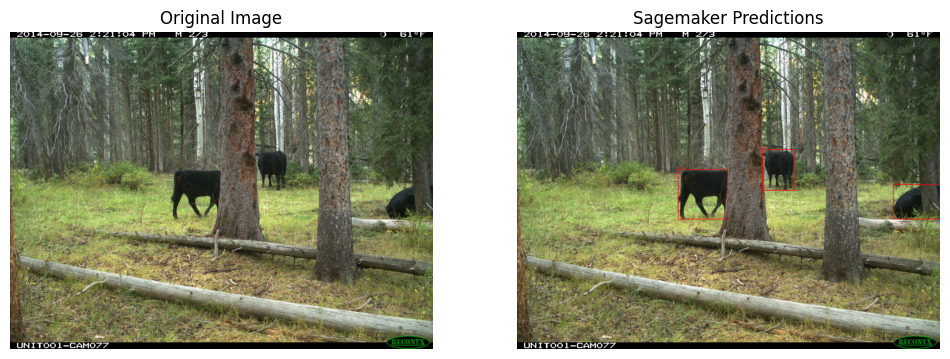


Sagemaker Prediction Results:
{
  "predictions": [
    {
      "filepath": "/tmp/temp_image.jpg",
      "classifications": {
        "classes": [
          "aca65aaa-8c6d-4b69-94de-842b08b13bd6;mammalia;cetartiodactyla;bovidae;bos;taurus;domestic cattle",
          "ce2e0e86-5580-4ab4-974a-4970753a140f;aves;pelecaniformes;ardeidae;bubulcus;ibis;cattle egret",
          "3d80f1d6-b1df-4966-9ff4-94053c7a902a;mammalia;carnivora;canidae;canis;familiaris;domestic dog",
          "18c5f185-04c8-43fc-9325-d38f7daa2700;mammalia;cetartiodactyla;bovidae;bison;bonasus;european bison",
          "9732cefb-6a08-49f6-b61e-b9a9054368c4;mammalia;cetartiodactyla;bovidae;syncerus;caffer;african buffalo"
        ],
        "scores": [
          0.9997690320014954,
          5.3176427172729746e-05,
          2.4364038836210966e-05,
          2.2216991055756807e-05,
          1.5053081369842403e-05
        ]
      },
      "detections": [
        {
          "category": "1",
          "label": "animal",
 

In [5]:
sess = boto3.Session(profile_name='animl')

# Initialize Sagemaker client
sagemaker_runtime = sess.client('runtime.sagemaker', region_name='us-west-2')

# Endpoint name
endpoint_name = 'speciesnet-v4-0-1a'

# Prepare payload for Sagemaker
sagemaker_payload = {
    "image_data": img_str
}

# Invoke endpoint
response = sagemaker_runtime.invoke_endpoint(
    EndpointName=endpoint_name,
    ContentType='application/json',
    Body=json.dumps(sagemaker_payload)
)

# Parse results
sagemaker_result = json.loads(response['Body'].read().decode())

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(original_image)
plt.axis('off')

# Display annotated image
sagemaker_annotated = draw_predictions(original_image, sagemaker_result)
plt.subplot(1, 2, 2)
plt.title('Sagemaker Predictions')
plt.imshow(sagemaker_annotated)
plt.axis('off')
plt.show()

# Print predictions
print("\nSagemaker Prediction Results:")
print(json.dumps(sagemaker_result, indent=2))

## Get Megadetector Predictions from SageMaker

[
  {
    "x1": 0.3802061378955841,
    "y1": 0.434901624917984,
    "x2": 0.49826210737228394,
    "y2": 0.5926240086555481,
    "confidence": 0.9541991353034973,
    "class": 1
  },
  {
    "x1": 0.5792825222015381,
    "y1": 0.3727113902568817,
    "x2": 0.655062735080719,
    "y2": 0.5021007061004639,
    "confidence": 0.9524310231208801,
    "class": 1
  },
  {
    "x1": 0.8886842727661133,
    "y1": 0.48295554518699646,
    "x2": 0.9999507665634155,
    "y2": 0.5927558541297913,
    "confidence": 0.9428881406784058,
    "class": 1
  },
  {
    "x1": 0.9195259809494019,
    "y1": 0.49111926555633545,
    "x2": 0.9709609150886536,
    "y2": 0.5849714875221252,
    "confidence": 0.00448004063218832,
    "class": 1
  },
  {
    "x1": 0.0,
    "y1": 0.6284118294715881,
    "x2": 0.025375042110681534,
    "y2": 0.7231143116950989,
    "confidence": 0.0028524689842015505,
    "class": 1
  },
  {
    "x1": 0.9922431707382202,
    "y1": 0.48390328884124756,
    "x2": 1.0,
    "y2": 0.5785

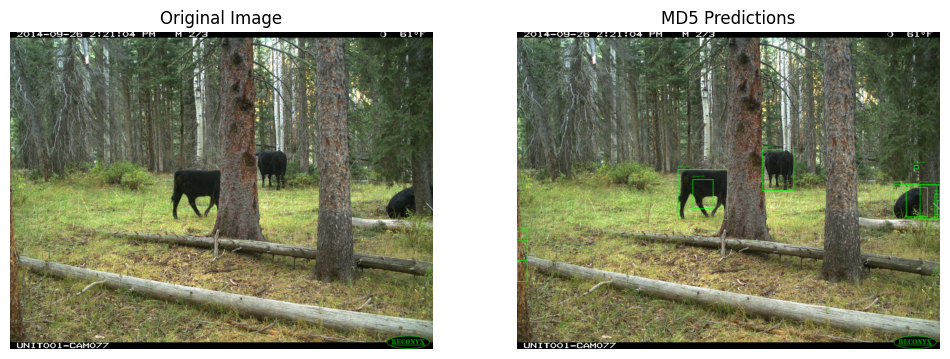

In [6]:
# Megadetector endpoint name
md5_endpoint_name = 'mdv5a-concurrency-20'

with open(test_image_path, 'rb') as f:
    img_bytes = f.read()

# Invoke endpoint
response = sagemaker_runtime.invoke_endpoint(
    EndpointName=md5_endpoint_name,
    ContentType='application/x-image',
    Body=img_bytes
)

# Parse results
md5_results = json.loads(response['Body'].read().decode())

print(json.dumps(md5_results, indent=2))

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(original_image)
plt.axis('off')

# Display annotated image
md5_annotated = draw_md5_detections(original_image, md5_results)
plt.subplot(1, 2, 2)
plt.title('MD5 Predictions')
plt.imshow(md5_annotated)
plt.axis('off')
plt.show()

## Use MD5 results to Run Speciesnet Classifer

{'predictions': [{'detections': [{'bbox': [0.3802061378955841, 0.434901624917984, 0.11805596947669983, 0.1577223837375641], 'conf': 0.9541991353034973, 'category': '1', 'label': 'animal'}, {'bbox': [0.5792825222015381, 0.3727113902568817, 0.07578021287918091, 0.12938931584358215], 'conf': 0.9524310231208801, 'category': '1', 'label': 'animal'}, {'bbox': [0.8886842727661133, 0.48295554518699646, 0.11126649379730225, 0.1098003089427948], 'conf': 0.9428881406784058, 'category': '1', 'label': 'animal'}]}]}


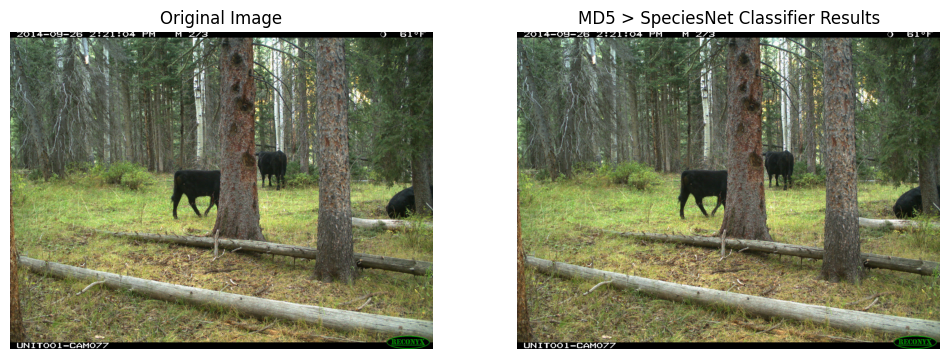


Sagemaker Prediction Results:
{
  "predictions": [
    {
      "filepath": "/tmp/temp_image.jpg",
      "classifications": {
        "classes": [
          "aca65aaa-8c6d-4b69-94de-842b08b13bd6;mammalia;cetartiodactyla;bovidae;bos;taurus;domestic cattle",
          "ce2e0e86-5580-4ab4-974a-4970753a140f;aves;pelecaniformes;ardeidae;bubulcus;ibis;cattle egret",
          "18c5f185-04c8-43fc-9325-d38f7daa2700;mammalia;cetartiodactyla;bovidae;bison;bonasus;european bison",
          "3d80f1d6-b1df-4966-9ff4-94053c7a902a;mammalia;carnivora;canidae;canis;familiaris;domestic dog",
          "9732cefb-6a08-49f6-b61e-b9a9054368c4;mammalia;cetartiodactyla;bovidae;syncerus;caffer;african buffalo"
        ],
        "scores": [
          0.9997128844261169,
          6.509164813905954e-05,
          3.700098386616446e-05,
          2.6971927582053468e-05,
          1.6489715562784113e-05
        ]
      }
    }
  ]
}


In [7]:
# Filter and convert md5 bbox to speciesnet
detections = convert_md_to_speciesnet(md5_results, confidence_threshold=0.40)
print(detections)

# Prepare payload
payload = {
    'image_data': img_str,
    'bbox': detections['predictions'][0]['detections'][0]['bbox'],
    'components': 'classifier'
}

# Invoke endpoint
response = sagemaker_runtime.invoke_endpoint(
    EndpointName=endpoint_name,
    ContentType='application/json',
    Body=json.dumps(payload)
)

# Parse results
sagemaker_result = json.loads(response['Body'].read().decode())

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(original_image)
plt.axis('off')

# Display annotated image
sagemaker_annotated = draw_predictions(original_image, sagemaker_result)
plt.subplot(1, 2, 2)
plt.title('MD5 > SpeciesNet Classifier Results')
plt.imshow(sagemaker_annotated)
plt.axis('off')
plt.show()

# Print predictions
print("\nSagemaker Prediction Results:")
print(json.dumps(sagemaker_result, indent=2))

# Done